<a href="https://colab.research.google.com/github/jmb45/GenAI/blob/main/Chatbot_Long_Term_Memory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Chat Interface with Long-Term Memroy**

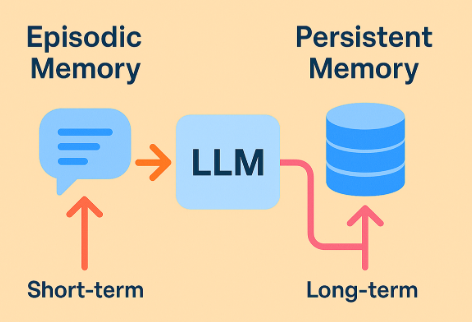

In [1]:
# Install the needed libraries
!pip install -qU langchain-google-genai

# The SQL memory features
!pip install -U langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


# **Transition from Short-Term to Long-Term Memory**

* In the short-term memory notebook, if we stopped the program and restarted it, the **chat_history** list would be empty and the AI would forget everything.

* Using **SQLChatMessageHistory** ensures the conversation survives even if we turn off the computer.

* **connection_string="sqlite:///joke_factory.db**
   * This tells the program to create a **SQLite Database** file on the computer named **joke_factory.db**
   
   * Before, memory was stored in a **Python list (temporary)**
   
   * But now, memory is stored in a **database file (permanent)**

* **session_id**
   * This is like a label on a folder.
   * If we set the ID to **science_comedian_v1**, the database saves all messages under that **folder**

---
* The best part of using **SQLChatMessageHistory** is that we no longer need to manually manage the list.

  * When we add a message, it is instantly written to the .db file.

  * When we start the program, it automatically reads the old messages from the .db file into the AI's context.

  ---
* **About SQLite**
   * Unlike MySQL, SQLite doesn't have a separate server process.
   
   * There is no **installing** a database service.
   
   * It is a library that is built-in to Python.
   
   * When we specify a filename such as **joke_factory.db**, the database engine simply starts running inside yotheur code

   * The entire database—including all tables, indexes, and the chat history—is stored in one single cross-platform file.

   * In production environments, LLMs use MySQL for **Long-Term Memory** primarily to handle scale and structured data.

   * If we want to build a **Gym Bot**  used by 5,000 people, we can't have 5,000 different .db files floating around. MySQL allows us to store every user's chat history in one massive table, using a user_id column to keep them separate.


  ---


In [3]:
import os
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage
from langchain_community.chat_message_histories import SQLChatMessageHistory

# 1. Setup
os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.1
)

while True:
  # The following section can be outside of the loop, if the user
  # wants to have long conversations with either Science or American History bots.
  # For the purpose of this exercise, I kept it inside the while loop because we
  # have only one message to the bots at a time, automatically exiting the corresponding sessions id.
  #---------------------------------------------------------
  # 1. THE MENU
  print("--- CHATBOT MENU ---")
  print("1. Science Facts")
  print("2. American History")
  choice = input("Select a topic to load: ")

  # 2. DYNAMIC SESSION MAPPING
  topic_map = {"1": "science_session", "2": "history_session"}
  current_session = topic_map.get(choice, "general_session")

  # 3. INITIALIZE HISTORY
  # The bot will ONLY see messages associated with this specific ID

  history = SQLChatMessageHistory(
    session_id=current_session,
    connection_string="sqlite:///chat_history.db"
  )
  #---------------------------------------------------------
  user_input = input("You: ")

  if user_input.lower() in ["exit", "quit", "bye"]:
      print("Goodbye!")
      break

  # Add user's message to the SQLite database
  history.add_user_message(user_input)

  # Get the AI response
  # We pass the ENTIRE history from the database to Gemini
  response = llm.invoke(history.messages)
  ai_text = response.content

  print(f"{current_session}: {ai_text}")

  # Save the AI's response to the SQLite database
  history.add_ai_message(ai_text)

--- CHATBOT MENU ---
1. Science Facts
2. American History
Select a topic to load: 1
You: The sun is a star
science_session: That's correct! The Sun is indeed a star, and it's the star at the center of our solar system.
--- CHATBOT MENU ---
1. Science Facts
2. American History
Select a topic to load: 2
You: What did I just say about the sun?
history_session: I'm sorry, but I don't have access to your previous conversations or what you might have said before this current interaction. I don't know what you just said about the sun.

If you'd like to tell me, or if you want to discuss the sun, please do!
--- CHATBOT MENU ---
1. Science Facts
2. American History
Select a topic to load: 1
You: What is the sun?
science_session: The Sun is the **star at the center of our solar system**. It is by far the most important source of energy for life on Earth.

Here's a breakdown of what the Sun is:

1.  **A Star:** Like all stars, the Sun is a massive, luminous ball of plasma (ionized gas) held toget

KeyboardInterrupt: Interrupted by user

# **Google Drive Persistence**

* By default, Colab files are deleted when you close the tab.

* To make this memory truly permanent by surviving even Colab timeouts, **mount** your Google Drive and **change the connection string**:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Change connection string to save inside your Drive
chat_history = SQLChatMessageHistory(
    session_id=session_id,
    connection_string="sqlite:////content/drive/MyDrive/joke_factory.db"
)

# **Extra Credit Analysis**

1. The bot was not able to remember what I said about the sun because of the way contextual memory works. In this notebook, we have two bots that are split by session ID. Since they are split like this, one bot cannot remember what I said to the other bot. Now, they still have general knowledge, which is called parametric memory. The parametric memory is filled with the facts that it learned during training, like what the sun is. But it does not have the chat history of what I said because of the split session IDs, which are required to provide the contextual memory.

2. Session IDs prevent context pollution because they only allow for certain contexts to be retained based on the corresponding session ID. For example, lets say I have the science bot and the history bot. If I get done talking to the science bot and swap to the history, I don't want this new bot to have any context. Otherwise it could start interjecting with stuff related to the science topics that I was talking about or trying to find relationships between science and history when that is not what I want. Even though they are in the same database file, the contexts are stored apart based on session ID so that only the proper ID can access the proper context.

# **AI CONVERSATION**

--- CHATBOT MENU ---
1. Science Facts
2. American History
Select a topic to load: 1  
You: The sun is a star  
science_session: That's correct! The Sun is indeed a star, and it's the star at the center of our solar system.  
--- CHATBOT MENU ---
1. Science Facts  
2. American History  
Select a topic to load: 2  
You: What did I just say about the sun?  
history_session: I'm sorry, but I don't have access to your previous conversations or what you might have said before this current interaction. I don't know what you just said about the sun.  

If you'd like to tell me, or if you want to discuss the sun, please do!  
--- CHATBOT MENU ---
1. Science Facts
2. American History
Select a topic to load: 1  
You: What is the sun?  
science_session: The Sun is the **star at the center of our solar system**. It is by far the most important source of energy for life on Earth.  

Here's a breakdown of what the Sun is:

1.  **A Star:** Like all stars, the Sun is a massive, luminous ball of plasma (ionized gas) held together by its own gravity. It generates its own light and heat through nuclear fusion.

2.  **Nuclear Fusion Powerhouse:** In its core, the Sun converts hydrogen atoms into helium atoms through a process called nuclear fusion. This process releases an enormous amount of energy, which radiates outwards, providing the light and heat we experience.

3.  **Composition:** It's primarily composed of hydrogen (about 73% of its mass) and helium (about 25% of its mass), with trace amounts of heavier elements like oxygen, carbon, neon, and iron.

4.  **Size and Mass:** The Sun is enormous compared to Earth. Its diameter is about 1.39 million kilometers (864,000 miles), which is about 109 times that of Earth. It accounts for about 99.86% of the total mass of the solar system. Despite its size relative to Earth, it's considered an average-sized star in the universe.

5.  **Temperature:** The Sun is incredibly hot. Its surface temperature is about 5,500 degrees Celsius (9,940 degrees Fahrenheit), while its core temperature is an astounding 15 million degrees Celsius (27 million degrees Fahrenheit).

6.  **Yellow Dwarf:** Astronomers classify the Sun as a "yellow dwarf" star (spectral type G2V). The "yellow" refers to the peak of its emitted light spectrum, though it actually emits light across all colors, appearing white to us when viewed from space.

7.  **Source of Life and Energy:** The Sun's energy drives almost all processes on Earth. It provides the light for photosynthesis, which forms the base of most food chains. It heats our planet, drives weather patterns, and is the ultimate source of most renewable energy (solar, wind, hydropower). Its gravity keeps Earth and all the other planets, asteroids, and comets in orbit around it.

In essence, the Sun is a gigantic, self-sustaining nuclear reactor that provides the light, heat, and gravitational anchor for our entire solar system.